# Playing with the `make_moons` dataset in PyTorch


In [2]:
import time
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from sklearn.datasets import make_moons


In [3]:
class Timer:
    def __init__(self):
        self.time = None

    def __enter__(self):
        self.time = time.time()

    def __exit__(self, exc_type, exc_value, exc_traceback):
        time_passed = time.time() - self.time
        print(f'** {time_passed:.2f} seconds.')


In [4]:
def plot_decision_boundary(X, y, model, steps=1000, cmap='Paired'):
    cmap = plt.get_cmap(cmap)

    # Define region of interest by data limits
    xmin, xmax = X[:, 0].min() - 1, X[:, 0].max() + 1
    ymin, ymax = X[:, 1].min() - 1, X[:, 1].max() + 1
    x_span = np.linspace(xmin, xmax, steps)
    y_span = np.linspace(ymin, ymax, steps)
    xx, yy = np.meshgrid(x_span, y_span)

    # Make predictions across region of interest
    model.eval()
    with torch.no_grad():
        inputs = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
        outputs = model(inputs)
        # Assuming binary classification with one output node or two output nodes
        if outputs.shape[1] > 1:
            _, labels = torch.max(outputs, 1)
        else:
            labels = (outputs > 0.5).int()
        labels = labels.cpu().numpy()

    # Plot decision boundary in region of interest
    z = labels.reshape(xx.shape)

    fig, ax = plt.subplots()
    ax.contourf(xx, yy, z, cmap=cmap, alpha=0.5)

    # Get predicted labels on training data and plot
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap, lw=0)

    return fig, ax


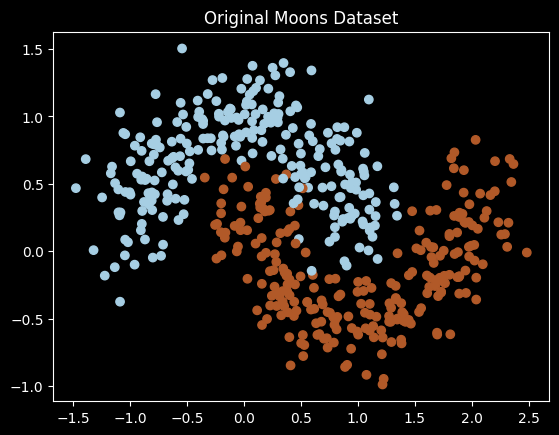

In [5]:
# 1. Generate the dataset
X, y = make_moons(n_samples=500, noise=0.2, random_state=42)

plt.scatter(X[:,0], X[:,1], c=y, cmap='Paired')
plt.title("Original Moons Dataset")
plt.show()


In [6]:
# 2. Define a simple neural network model
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(2, 16),
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.layers(x)

model = SimpleNN()
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)


In [7]:
# 3. Training loop
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32).reshape(-1, 1)

print("Starting training...")
with Timer():
    for epoch in range(1001):
        # Forward pass
        model.train()
        outputs = model(X_tensor)
        loss = criterion(outputs, y_tensor)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if epoch % 200 == 0:
            print(f"Epoch [{epoch}/1000], Loss: {loss.item():.4f}")


Starting training...
Epoch [0/1000], Loss: 0.7028
Epoch [200/1000], Loss: 0.0389
Epoch [400/1000], Loss: 0.0311
Epoch [600/1000], Loss: 0.0283
Epoch [800/1000], Loss: 0.0266
Epoch [1000/1000], Loss: 0.0251
** 1.97 seconds.


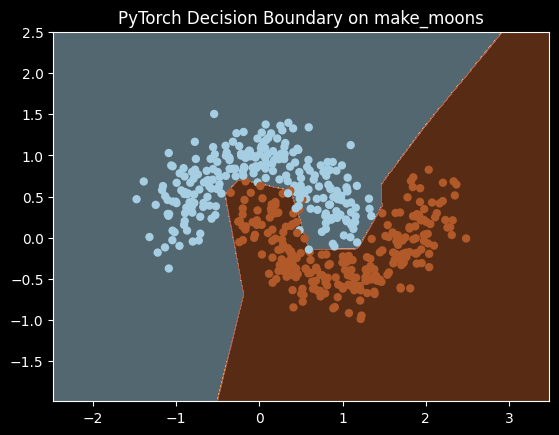

In [8]:
# 4. Plot results
plot_decision_boundary(X, y, model)
plt.title("PyTorch Decision Boundary on make_moons")
plt.show()
